In [28]:
!pip install keras tensorflow

In [29]:
import os
import numpy as np
import tensorflow as tf
import keras as keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from PIL import Image
import zipfile
from google.colab import drive
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Constants
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 20
VALIDATION_SPLIT = 0.2

Checking paths...
Train path exists: True
Test path exists: True

Loading training data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading class: digit_0 (label: 0)
Loading class: digit_1 (label: 1)
Loading class: digit_2 (label: 2)
Loading class: digit_3 (label: 3)
Loading class: digit_4 (label: 4)
Loading class: digit_5 (label: 5)
Loading class: digit_6 (label: 6)
Loading class: digit_7 (label: 7)
Loading class: digit_8 (label: 8)
Loading class: digit_9 (label: 9)

Loading testing data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading class: digit_0 (label: 0)
Loading class: digit_1 (label: 1)
Loading class: digit_2 (label: 2)
Loading class: digit_3 (label: 3)
Loading class: digit_4 (label: 4)
Loading class: digit_5 (label: 5)
Loading class: digit_6 (label: 6)
Loading class: digit_7 (label: 7)
Loading class: digit

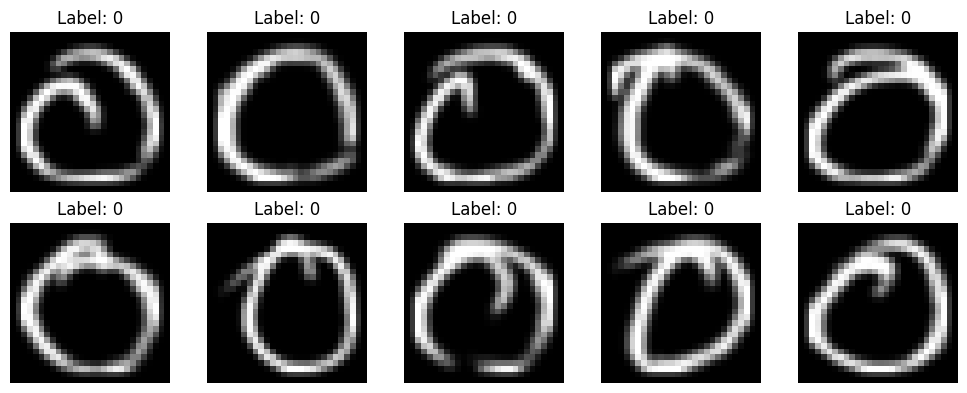

In [32]:

train_dir = "/content/drive/MyDrive/ai Workshop Dataset/DevanagariDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/ai Workshop Dataset/DevanagariDigitDataset/Test/"

def load_images_from_folder(folder):
    images = []
    labels = []

    # Check if folder exists
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}. Please check your path.")

    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    print(f"Found classes: {class_names}")

    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        print(f"Loading class: {class_name} (label: {label})")

        for filename in os.listdir(class_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                img_path = os.path.join(class_path, filename)
                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("L")  # Convert to grayscale
                    img = img.resize((IMG_WIDTH, IMG_HEIGHT))  # Resize to (28,28)
                    img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue

    return np.array(images), np.array(labels)

# Verify paths exist before loading
print("Checking paths...")
print(f"Train path exists: {os.path.exists(train_dir)}")
print(f"Test path exists: {os.path.exists(test_dir)}")

# Load training and testing datasets
print("\nLoading training data...")
x_train, y_train = load_images_from_folder(train_dir)

print("\nLoading testing data...")
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)  # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"\nTraining set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [33]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(NUM_CLASSES, activation="softmax"),
  ]
)

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [36]:
batch_size = 128
epochs =150
# Callbacks
callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
]
# Train the model with callbacks and validation split
history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.15,
callbacks=callbacks,
)

Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1206 - loss: 2.2310 - val_accuracy: 0.0000e+00 - val_loss: 3.9763
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1282 - loss: 2.1880 - val_accuracy: 0.0000e+00 - val_loss: 4.4302
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1312 - loss: 2.1840 - val_accuracy: 0.0000e+00 - val_loss: 4.6989
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1352 - loss: 2.1818 - val_accuracy: 0.0000e+00 - val_loss: 4.8901
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1390 - loss: 2.1802 - val_accuracy: 0.0000e+00 - val_loss: 5.0385
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1425 - loss: 2.1789 - val_accuracy: 0.0000e+00 - val_loss: 5.1598
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1469 - loss: 2.1777 - val_accuracy: 0.0000e+00 - val_loss: 5.2622
Epoch 8/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.15

In [37]:
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

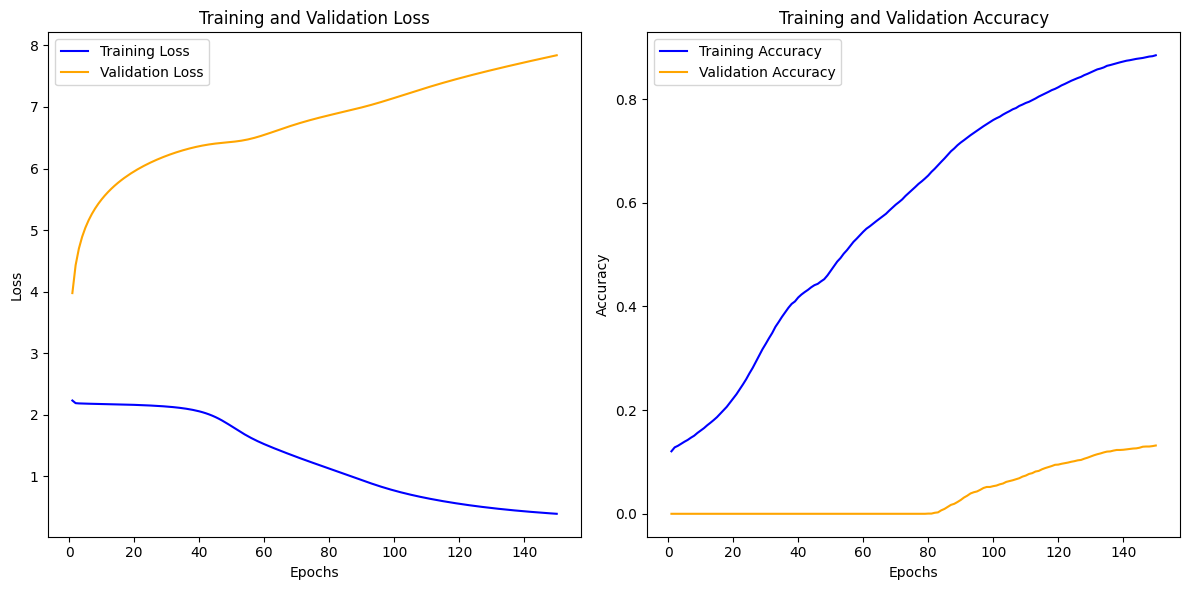

In [38]:
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7740 - loss: 1.5068
Test accuracy: 0.7740


In [40]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0
